# Zweite explorative Analyse: Wetter als Unsicherheitssignal, vergangene Preise, Stabilität

Fortsetzung von [`01_eda.ipynb`](01_eda.ipynb) mit den Hypothesen **H9 bis H12**. Die Zusammenfassung steht in [`docs/eda.md`](../docs/eda.md).

| # | Hypothese |
|---|---|
| H9 | Wechselhaftes Wetter macht die Systembilanz unruhiger, und der Preis streut breiter. |
| H10 | Weitere Wettervariablen (Temperatur, Wind, Niederschlag, Feuchte, Bewölkung nach Höhe) tragen zusätzlich zur Strahlung bei. |
| H11 | Das Preisniveau bis D−2 sagt etwas über den Liefertag. |
| H12 | Die Zusammenhänge sind über die Monate stabil. |

**Zeitraum:** nur Viertelstunden mit finalem Preis, 01.01. bis 31.08.2026. Damit hängen die Ergebnisse nicht davon ab, welcher Snapshot der Regelzonenbilanz gerade der neueste ist.

**Leak-Regeln wie in der ersten Runde:** Wetter nur aus dem Lauf D−2 18 UTC (über `weather_to_quarter_hours` bzw. `site_spread`), vergangene Preise nur über `known_at_issue()`. Zusammenhänge derselben Viertelstunde mit TSI oder Preis sind beschreibend, keine Merkmale.

## Setup

In [1]:
import datetime as dt
import os
import random
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The notebook runs from notebooks/; all paths are relative to the project root.
if Path.cwd().name == "notebooks":
    os.chdir("..")

from energy_price import eda
from energy_price.figures_data import BLUE, CATEGORICAL, INK, INK_2, MUTED, SURFACE, style

# figures_data switches matplotlib to Agg for `make figures`; back to inline so the figures show here.
%matplotlib inline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

style()
FIGURES = Path("docs/figures")
RED = "#e34948"  # red pole of the diverging pair of the reference palette
TZ = "Europe/Zurich"
MONTHS = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun", "Jul", "Aug"]

print(f"python {sys.version.split()[0]} ({os.path.relpath(sys.executable)})  # relative: no local home path in the repo")
print(f"pandas {pd.__version__}, numpy {np.__version__}, matplotlib {matplotlib.__version__}")

python 3.14.7 (.venv/bin/python)  # relative: no local home path in the repo
pandas 3.0.6, numpy 2.5.3, matplotlib 3.11.2


In [2]:
def save(fig: plt.Figure, name: str) -> None:
    fig.savefig(FIGURES / name, dpi=150, bbox_inches="tight")


def spearman(frame: pd.DataFrame, a: str, b: str) -> float:
    # DataFrame.corr computes Spearman without scipy (Series.corr would need it)
    return frame[[a, b]].corr(method="spearman").iloc[0, 1]


def width(s: pd.Series) -> float:
    return s.quantile(0.9) - s.quantile(0.1)

Kein Zufall im Notebook; der Seed ist trotzdem gesetzt.

## Daten

In [3]:
prices = pd.read_parquet("data/processed/balance_prices.parquet")
prices = prices[prices["regime"] == "single_price"].reset_index(drop=True)
cab = pd.read_parquet("data/processed/control_area_balance.parquet")
weather = pd.read_parquet("data/processed/weather_forecasts.parquet")
sites = pd.read_csv("data/meta/weather_sites.csv")
weights = sites.set_index("site")["pv_share"]

WEATHER = ["shortwave_radiation", "direct_radiation", "diffuse_radiation", "direct_normal_irradiance", "sunshine_duration",
           "cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "temperature_2m",
           "relative_humidity_2m", "precipitation", "snowfall", "wind_speed_10m", "wind_speed_100m"]
mean_weather = eda.weather_to_quarter_hours(weather, weights, WEATHER)
spread = eda.site_spread(weather, ["shortwave_radiation"]).add_suffix("_spread")

qh = cab[["timestamp_utc", "timestamp_local", "tsi_mw"]].merge(prices[["timestamp_utc", "aep_ct_kwh"]], on="timestamp_utc")
qh = qh.merge(mean_weather, left_on="timestamp_utc", right_index=True, how="left")
qh = qh.merge(spread, left_on="timestamp_utc", right_index=True, how="left")
local = qh["timestamp_local"]
qh = qh.assign(hour=local.dt.hour, month=local.dt.month, date=local.dt.date, slot=eda.clock_slot(local),
               short=qh["tsi_mw"] < 0, abs_tsi=qh["tsi_mw"].abs())
print(qh.shape, qh["date"].min(), "..", qh["date"].max())
print("missing radiation on:", sorted(set(qh.loc[qh["shortwave_radiation"].isna(), "date"])))

(23324, 26) 2026-01-01 .. 2026-08-31
missing radiation on: [datetime.date(2026, 6, 24)]


23'324 Viertelstunden, wie in der ersten Runde. Die Strahlung fehlt nur am 24.06.2026 (Archivlücke).

## H9: Macht wechselhaftes Wetter die Systembilanz unruhiger?

**Hypothese:** In Viertelstunden mit unsicherer Wetterlage ist |TSI| grösser und der Preis streut breiter.

Die *Abweichung* der Sonne von der Prognose ist um 11:00 unbekannt. Ob die Lage unsicher ist, lässt sich aber aus der Prognose selbst schätzen. Drei Masse, alle aus dem Lauf D−2 18 UTC:
1. **Bewölkung** (PV-gewichtet): klar (unter 20 %), wechselnd (20 bis 80 %), bedeckt (über 80 %).
2. **Streuung zwischen den Standorten:** Standardabweichung der Strahlungsprognose über die sechs Standorte, geteilt durch die mittlere Strahlung (sonst misst sie nur, wie hell es ist).
3. **Sprünge über den Tag:** mittlere Änderung der Strahlungsprognose von Stunde zu Stunde.

Nur Tageslicht (Strahlung über 50 W/m²), getrennt nach Tageszeit, damit nicht die Uhrzeit den Effekt erzeugt. Breite = P90 minus P10 des Preises.

In [4]:
day = qh[qh["shortwave_radiation"] > 50].copy()
day["cloud"] = pd.cut(day["cloud_cover"], [-1, 20, 80, 101], labels=["klar", "wechselnd", "bedeckt"])
day["daytime"] = pd.cut(day["hour"], [0, 10, 14, 24], labels=["bis 10 Uhr", "10 bis 14 Uhr", "ab 14 Uhr"], right=False)
by_cloud = day.groupby(["daytime", "cloud"], observed=True).agg(
    quarter_hours=("abs_tsi", "size"), abs_tsi_median=("abs_tsi", "median"),
    price_width=("aep_ct_kwh", width), negative=("aep_ct_kwh", lambda s: (s < 0).mean()))
by_cloud.round(2)

quarter_hours  abs_tsi_median  price_width  negative
daytime       cloud                                                          
bis 10 Uhr    klar                 872           50.55        27.19      0.12
              wechselnd           1096           67.59        27.51      0.11
              bedeckt              568           79.08        26.26      0.11
10 bis 14 Uhr klar                1040           62.09        32.00      0.27
              wechselnd           1672           93.49        36.36      0.23
              bedeckt             1156          105.86        35.08      0.16
ab 14 Uhr     klar                1312           57.01        33.18      0.20
              wechselnd           2424           82.20        35.68      0.19
              bedeckt             1160           80.70        26.44      0.10

Hängt das nur an der Saison (bedeckte Tage eher im Winter)? Gleicher Vergleich **pro Monat**:

In [5]:
cloud_month = day.pivot_table(index="month", columns="cloud", values="abs_tsi", aggfunc="median", observed=True)
width_month = day.pivot_table(index="month", columns="cloud", values="aep_ct_kwh", aggfunc=width, observed=True)
print("median |TSI| [MW]\n", cloud_month.round(0).to_string())
print("\nprice width P90-P10 [ct/kWh]\n", width_month.round(1).to_string())

median |TSI| [MW]
 cloud  klar  wechselnd  bedeckt
month                          
1      94.0      109.0     79.0
2      82.0       88.0     83.0
3      62.0       80.0     90.0
4      76.0       98.0     90.0
5      53.0       84.0     84.0
6      45.0       70.0     97.0
7      53.0       83.0    117.0
8      48.0       77.0     99.0

price width P90-P10 [ct/kWh]
 cloud  klar  wechselnd  bedeckt
month                          
1      19.7       20.1     21.7
2      23.8       19.9     17.7
3      23.1       28.8     32.5
4      30.0       64.2     34.1
5      35.2       33.6     33.9
6      29.5       37.0     37.0
7      33.9       34.3     36.0
8      31.9       35.9     44.3


In [6]:
day["rel_spread"] = day["shortwave_radiation_spread"] / day["shortwave_radiation"]
day["spread_class"] = day.groupby("daytime", observed=True)["rel_spread"].transform(
    lambda s: pd.qcut(s, 3, labels=["tief", "mittel", "hoch"]))
day.groupby(["daytime", "spread_class"], observed=True).agg(
    abs_tsi_median=("abs_tsi", "median"), price_width=("aep_ct_kwh", width)).round(2)

abs_tsi_median  price_width
daytime       spread_class                             
bis 10 Uhr    tief                   52.66        30.94
              mittel                 54.50        23.88
              hoch                   80.42        25.77
10 bis 14 Uhr tief                   62.50        32.69
              mittel                 97.47        35.60
              hoch                  107.11        33.30
ab 14 Uhr     tief                   64.30        38.07
              mittel                 75.00        30.16
              hoch                   84.93        29.04

In [7]:
jumps = eda.daily_mean_abs_change(mean_weather["shortwave_radiation"]).rename("jumps")
daily = day.groupby("date").agg(abs_tsi=("abs_tsi", "mean"), price_width=("aep_ct_kwh", width),
                                radiation=("shortwave_radiation", "mean"), month=("month", "first")).join(jumps)
daily["rel_jumps"] = daily["jumps"] / daily["radiation"]
print(f"{len(daily)} days")
for target in ["abs_tsi", "price_width"]:
    within = daily.groupby("month").apply(lambda g: spearman(g, "rel_jumps", target), include_groups=False)
    print(f"rel_jumps ~ {target:11s}: all days {spearman(daily, 'rel_jumps', target):+.2f}, "
          f"within months median {within.median():+.2f} (range {within.min():+.2f} .. {within.max():+.2f})")
print(f"radiation ~ price_width: {spearman(daily, 'radiation', 'price_width'):+.2f}")

242 days
rel_jumps ~ abs_tsi    : all days +0.08, within months median +0.22 (range -0.18 .. +0.47)
rel_jumps ~ price_width: all days +0.32, within months median -0.16 (range -0.24 .. +0.38)
radiation ~ price_width: +0.47


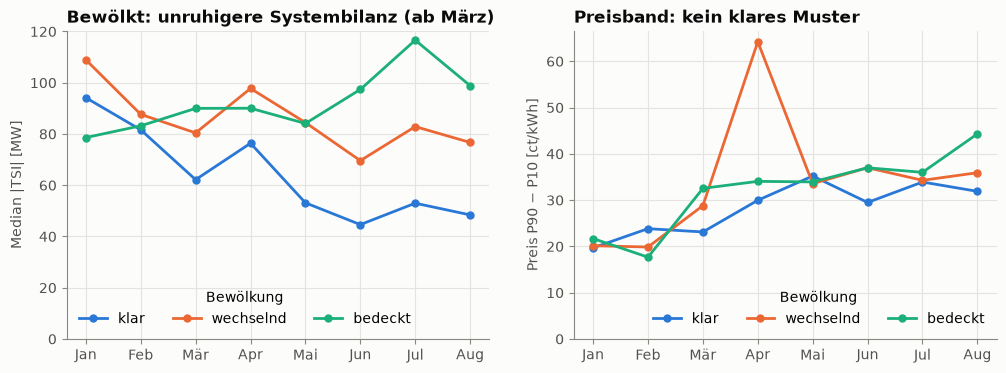

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
classes = ["klar", "wechselnd", "bedeckt"]
for colour, cls in zip(CATEGORICAL, classes):
    axes[0].plot(range(len(cloud_month)), cloud_month[cls], color=colour, marker="o", markersize=5, label=cls)
    axes[1].plot(range(len(width_month)), width_month[cls], color=colour, marker="o", markersize=5, label=cls)
for ax, where in zip(axes, ["lower left", "lower right"]):
    ax.set_xticks(range(len(cloud_month)), [MONTHS[m - 1] for m in cloud_month.index])
    ax.legend(loc=where, title="Bewölkung", ncols=3)
axes[0].set(ylabel="Median |TSI| [MW]", ylim=(0, None), title="Bewölkt: unruhigere Systembilanz (ab März)")
axes[1].set(ylabel="Preis P90 − P10 [ct/kWh]", ylim=(0, None), title="Preisband: kein klares Muster")
save(fig, "eda2_weather_uncertainty.png")
plt.show()

**F (H9):** Macht wechselhaftes Wetter die Systembilanz unruhiger? **A: Die Systembilanz ja, das Preisband nicht.** Teilweise bestätigt.
- **Bewölkung:** Zwischen 10 und 14 Uhr liegt das mittlere |TSI| (Median) bei **62 MW**, wenn es klar ist, bei 93 MW bei wechselnder und bei **106 MW** bei bedeckter Bewölkung. Von März bis August ist |TSI| bei klarem Himmel in **jedem** Monat am kleinsten, im Juli zum Beispiel 53 gegenüber 83 und 117 MW. Im Januar und Februar gilt das nicht; dort spielt die PV kaum eine Rolle.
- **Anders als erwartet** ist nicht „wechselnd“ am unruhigsten, sondern im Sommer „bedeckt“. Eine Erklärung ist nicht geprüft.
- **Streuung zwischen den Standorten:** Im obersten Drittel ist |TSI| zu jeder Tageszeit grösser als im untersten (bis 10 Uhr 53 gegenüber 80 MW, 10 bis 14 Uhr 63 gegenüber 107 MW, ab 14 Uhr 64 gegenüber 85 MW).
- **Sprünge über den Tag:** schwach. Innerhalb der Monate liegt die Rangkorrelation mit |TSI| im Median bei +0.22, schwankt aber zwischen −0.18 und +0.47.
- **Preisband:** keine durchgehende Ordnung nach Bewölkung; die Monatswerte liegen meist nahe beieinander, mit einem einzelnen Ausreisser im April (wechselnd, 64 ct/kWh). Die Breite folgt vor allem der Saison: Über alle Tage hängt sie mit der Tagesstrahlung zusammen (+0.47), innerhalb der Monate mit den Sprüngen nicht (Median −0.16).
- **Folge:** Bewölkung und Standort-Streuung sind Kandidaten für die **Grösse** der Abweichung, etwa in einem Modell, das Richtung und Preis getrennt behandelt. Als direkte Merkmale für die Breite des Preisbands sind sie schwach. Ob sie im Modell helfen, entscheidet der Backtest.

## H10: Tragen weitere Wettervariablen zusätzlich zur Strahlung bei?

**Hypothese:** Temperatur, Wind, Niederschlag, Feuchte und Bewölkung nach Höhe hängen mit Preis oder |TSI| zusammen, auch bei gleicher Uhrzeit und gleicher Strahlung.

Über alle Viertelstunden gemessen würde jede Variable vor allem Tageszeit und Saison spiegeln. Darum die Rangkorrelation **innerhalb von Schichten**: pro Stunde und Drittel der Strahlung (Tageslicht), dann der Median über die Schichten.

In [9]:
day["radiation_third"] = day.groupby("hour")["shortwave_radiation"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 3, labels=False))
candidates = ["cloud_cover", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high", "temperature_2m",
              "relative_humidity_2m", "precipitation", "snowfall", "wind_speed_10m", "wind_speed_100m"]
rows = []
for var in candidates:
    strata = [g for _, g in day.groupby(["hour", "radiation_third"]) if len(g) > 50 and g[var].nunique() > 2]
    rows.append({"variable": var, "strata": len(strata),
                 "price": np.nanmedian([spearman(g, var, "aep_ct_kwh") for g in strata]),
                 "abs_tsi": np.nanmedian([spearman(g, var, "abs_tsi") for g in strata])})
within_strata = pd.DataFrame(rows).set_index("variable")
within_strata.round(3)

,strata,price,abs_tsi
variable,,,
cloud_cover,45,0.009,0.072
cloud_cover_low,45,0.022,0.058
cloud_cover_mid,45,0.002,0.069
cloud_cover_high,45,-0.024,0.059
temperature_2m,45,0.017,-0.005
relative_humidity_2m,45,0.013,0.064
precipitation,42,0.006,0.087
snowfall,19,0.072,-0.040
wind_speed_10m,45,-0.018,0.033


Zum Vergleich die Strahlung selbst innerhalb derselben Stunden (ohne Schichtung nach Strahlung), und die Nacht, in der die Strahlung keine Rolle spielt:

In [10]:
by_hour = [g for _, g in day.groupby("hour") if len(g) > 50]
print(f"radiation ~ price within hours (daylight): median {np.nanmedian([spearman(g, 'shortwave_radiation', 'aep_ct_kwh') for g in by_hour]):+.2f}")
night = qh[qh["shortwave_radiation"] <= 50]
for var in ["temperature_2m", "wind_speed_100m", "relative_humidity_2m"]:
    r = [spearman(g, var, "aep_ct_kwh") for _, g in night.groupby("hour")]
    print(f"night, {var:20s} ~ price within hours: median {np.nanmedian(r):+.2f}")

radiation ~ price within hours (daylight): median -0.16
night, temperature_2m       ~ price within hours: median +0.05
night, wind_speed_100m      ~ price within hours: median -0.04
night, relative_humidity_2m ~ price within hours: median -0.03


In [11]:
corr = qh[WEATHER].corr(method="spearman").abs()
redundant = [(a, b, round(corr.loc[a, b], 2)) for i, a in enumerate(WEATHER) for b in WEATHER[i + 1:] if corr.loc[a, b] > 0.9]
pd.DataFrame(redundant, columns=["variable", "variable_2", "abs_spearman"])

,variable,variable_2,abs_spearman
0,shortwave_radiation,direct_radiation,0.99
1,shortwave_radiation,diffuse_radiation,0.95
2,shortwave_radiation,direct_normal_irradiance,0.96
3,shortwave_radiation,sunshine_duration,0.92
4,direct_radiation,diffuse_radiation,0.92
5,direct_radiation,direct_normal_irradiance,0.99
6,direct_radiation,sunshine_duration,0.95
7,direct_normal_irradiance,sunshine_duration,0.96


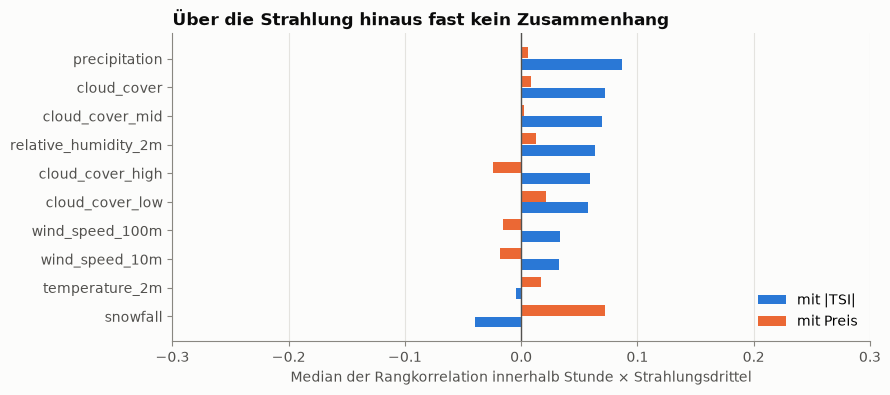

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
order = within_strata.sort_values("abs_tsi").index
y = np.arange(len(order))
ax.barh(y - 0.2, within_strata.loc[order, "abs_tsi"], height=0.38, color=BLUE, label="mit |TSI|")
ax.barh(y + 0.2, within_strata.loc[order, "price"], height=0.38, color=CATEGORICAL[1], label="mit Preis")
ax.axvline(0, color=INK_2, linewidth=1)
ax.set_yticks(y, order)
ax.set(xlim=(-0.3, 0.3), xlabel="Median der Rangkorrelation innerhalb Stunde × Strahlungsdrittel",
       title="Über die Strahlung hinaus fast kein Zusammenhang")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
save(fig, "eda2_weather_variables.png")
plt.show()

**F (H10):** Tragen weitere Wettervariablen zusätzlich zur Strahlung bei? **A: Nein.** Widerlegt.
- Innerhalb gleicher Stunde und gleichen Strahlungsdrittels liegen alle Mediane der Rangkorrelation nahe null: mit |TSI| zwischen −0.04 und +0.09, mit dem Preis zwischen −0.02 und +0.07. Zum Vergleich: die Strahlung selbst innerhalb derselben Stunden −0.16 mit dem Preis.
- In der Nacht, wo die Strahlung keine Rolle spielt, ebenso: Temperatur +0.05, Wind 100 m −0.04, Feuchte −0.03.
- **Redundant:** Die fünf Strahlungsvariablen (Global-, Direkt-, Diffusstrahlung, Direktnormalstrahlung, Sonnenscheindauer) hängen paarweise mit 0.92 bis 0.99 zusammen.
- **Empfehlung Wettervariablen:**
  - ins Modell: `shortwave_radiation` (Niveau und Steigung über die Stunde, H3 und H8) und `cloud_cover` oder die Standort-Streuung (H9);
  - vorerst weglassen: die übrigen vier Strahlungsvariablen, Temperatur, Wind, Feuchte, Niederschlag und Schneefall.
- **Vorbehalt:** Die Temperatur könnte im Herbst und Winter (Heizlast) wichtiger werden. Januar bis März zeigen das nicht; Herbstmonate fehlen in den Daten.

## H11: Sagt das Preisniveau bis D−2 etwas über den Liefertag?

**Hypothese:** Der Preis derselben Viertelstunde einige Tage zuvor und Quantile über die letzten Wochen hängen mit dem Preis am Liefertag zusammen.

Abstand ab 2 Tagen ist für jede Zielviertelstunde erlaubt (Ende D−2). **Vorbehalt:** Die Preise sind final; um 11:00 gab es nur provisorische Werte. Wie gross der Unterschied ist, misst ein eigenes Issue nach dem 21.10.2026.

In [13]:
price_frame = prices[["timestamp_local", "aep_ct_kwh"]]
pairs = eda.same_slot_pairs(price_frame, [2, 3, 7, 14, 28])
by_lag = pairs.groupby("lag_days").apply(lambda g: spearman(g, "value", "earlier"), include_groups=False).rename("spearman")
pairs["daytime"] = pd.cut(pairs["slot"] // 4, [0, 6, 10, 16, 20, 24], right=False,
                          labels=["0 bis 6", "6 bis 10", "10 bis 16", "16 bis 20", "20 bis 24"])
lag2 = pairs[pairs["lag_days"] == 2].groupby("daytime", observed=True).apply(
    lambda g: spearman(g, "value", "earlier"), include_groups=False)
daily_median = price_frame.groupby(price_frame["timestamp_local"].dt.date)["aep_ct_kwh"].median()
print("same quarter hour, by lag:", by_lag.round(3).to_dict())
print("lag 2 by time of day:", lag2.round(2).to_dict())
print("daily median price, autocorrelation:", {k: round(daily_median.autocorr(k), 3) for k in [2, 3, 7, 14]})

same quarter hour, by lag: {2: 0.158, 3: 0.127, 7: 0.123, 14: 0.131, 28: 0.106}
lag 2 by time of day: {'0 bis 6': 0.16, '6 bis 10': 0.1, '10 bis 16': 0.12, '16 bis 20': 0.17, '20 bis 24': 0.19}
daily median price, autocorrelation: {2: np.float64(0.217), 3: np.float64(0.111), 7: np.float64(0.002), 14: np.float64(0.102)}


Wie gut beschreiben **Quantile der Vergangenheit** den Liefertag? Für jeden Liefertag: P10, P50 und P90 je Viertelstunde des Tages aus den letzten W Tagen bis D−2 (`eda.past_slot_quantiles`), dann Abdeckung des Intervalls (Ziel 80 %), mittlere Breite und MAE des Medians. „alles“ heisst: alle Tage seit 01.01. Verglichen wird auf denselben Liefertagen (ab dem Tag, an dem auch das 56-Tage-Fenster voll ist).

Das ist eine Vorschau auf die naive Baseline, **keine** Modellbewertung; der Vergleich mit dem Pinball-Loss gehört ins Baseline-Issue.

In [14]:
days = sorted(set(price_frame["timestamp_local"].dt.date))
actual = price_frame.assign(slot=eda.clock_slot(price_frame["timestamp_local"]), date=price_frame["timestamp_local"].dt.date)
actual_by_day = {d: g.groupby("slot")["aep_ct_kwh"].mean() for d, g in actual.groupby("date")}
WINDOWS = {"7 Tage": 7, "14 Tage": 14, "28 Tage": 28, "56 Tage": 56, "alles": 400}
start = days[0] + dt.timedelta(days=1 + 56)  # first delivery day with a full 56-day window
rows = []
for name, w in WINDOWS.items():
    for d in [d for d in days if d >= start]:
        q = eda.past_slot_quantiles(price_frame, d, w).join(actual_by_day[d].rename("actual"), how="inner")
        rows.append({"window": name, "date": d,
                     "coverage": ((q["actual"] >= q[0.1]) & (q["actual"] <= q[0.9])).mean(),
                     "width": (q[0.9] - q[0.1]).mean(), "mae": (q["actual"] - q[0.5]).abs().mean()})
windows = pd.DataFrame(rows)
summary = windows.groupby("window", sort=False)[["coverage", "width", "mae"]].mean()
print(f"{windows['date'].nunique()} delivery days from {start}")
summary.round(3)

186 delivery days from 2026-02-27


,coverage,width,mae
window,,,
7 Tage,0.606,22.949,10.484
14 Tage,0.683,24.240,9.993
28 Tage,0.723,24.959,9.847
56 Tage,0.746,24.715,9.716
alles,0.728,22.322,9.730


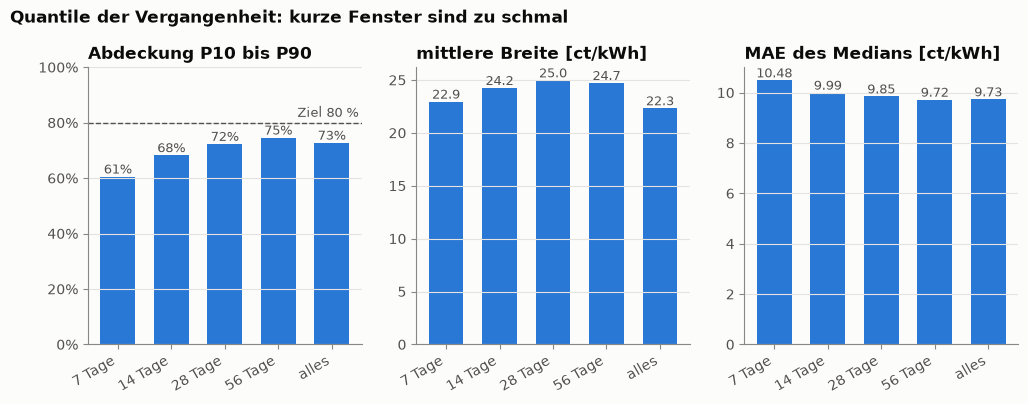

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
x = range(len(summary))
for ax, col, label, fmt in [(axes[0], "coverage", "Abdeckung P10 bis P90", "{:.0%}"),
                            (axes[1], "width", "mittlere Breite [ct/kWh]", "{:.1f}"),
                            (axes[2], "mae", "MAE des Medians [ct/kWh]", "{:.2f}")]:
    bars = ax.bar(x, summary[col], color=BLUE, width=0.65)
    for rect, v in zip(bars, summary[col]):
        ax.text(rect.get_x() + rect.get_width() / 2, v, fmt.format(v), ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set_xticks(x, summary.index, rotation=30, ha="right")
    ax.set(title=label)
    ax.grid(axis="x", visible=False)
axes[0].axhline(0.8, color=INK_2, linewidth=1, linestyle="--")
axes[0].text(len(summary) - 0.5, 0.81, "Ziel 80 %", ha="right", va="bottom", color=INK_2, fontsize=9)
axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
axes[0].set_ylim(0, 1)
fig.suptitle("Quantile der Vergangenheit: kurze Fenster sind zu schmal", x=0.06, y=1.04, ha="left", fontweight="bold", color=INK)
save(fig, "eda2_past_windows.png")
plt.show()

**F (H11):** Sagt das Preisniveau bis D−2 etwas über den Liefertag? **A: Nur schwach.**
- **Gleiche Viertelstunde einige Tage zuvor:** Rangkorrelation 0.16 nach 2 Tagen, 0.13 nach 3, 0.12 nach 7, 0.13 nach 14 und 0.11 nach 28 Tagen; je nach Tageszeit 0.10 bis 0.19. Der Tagesmedian hat eine Autokorrelation von 0.22 nach 2 Tagen, 0.11 nach 3 und 0.00 nach 7.
- **Quantile der Vergangenheit sind zu schmal.** Abdeckung von P10 bis P90 statt der angestrebten 80 %: 61 % bei 7 Tagen, 68 % bei 14, 72 % bei 28, **75 % bei 56 Tagen**, 73 % mit allen Daten seit Januar. Der MAE des Medians liegt zwischen 9.7 und 10.5 ct/kWh, am tiefsten bei 56 Tagen und „alles“.
- **„alles“ ist schmaler als 56 Tage** (22.3 gegenüber 24.7 ct/kWh) und deckt schlechter ab, weil es die ruhigen Wintermonate einmischt (siehe H12).
- **Folge für die Baseline:** mindestens 8 Wochen Fenster. Auch dann ist das Band zu schmal; ein Modell muss es mit Merkmalen (Uhrzeit, Position in der Stunde, Strahlung, Saison) besser setzen oder nachträglich kalibrieren. Vergangene Preise allein reichen nicht.
- **Vorbehalt:** Alle Werte sind final. Um 11:00 gab es nur provisorische; der Unterschied wird nach dem 21.10.2026 gemessen.

## H12: Sind die Zusammenhänge über die Monate stabil?

**Hypothese:** Preisverteilung, Strahlung und Preis (H3), das Kippen in der Stunde (H8) und das Tagesprofil (H7) ändern sich von Monat zu Monat nicht grundlegend.

Als Massstab für „grundlegend“ dient das Rauschen *innerhalb* eines Monats: der KS-Abstand zwischen der ersten und der zweiten Monatshälfte.

In [16]:
months = sorted(qh["month"].unique())
trend = eda.within_hour_trend(qh)
trend["month"] = pd.to_datetime(trend["date"]).dt.month
monthly = pd.DataFrame({
    "P10": qh.groupby("month")["aep_ct_kwh"].quantile(0.1),
    "P50": qh.groupby("month")["aep_ct_kwh"].median(),
    "P90": qh.groupby("month")["aep_ct_kwh"].quantile(0.9),
    "negative": qh.groupby("month")["aep_ct_kwh"].apply(lambda s: (s < 0).mean()),
    "short": qh.groupby("month")["short"].mean(),
    "rad_price_long": day[~day["short"]].groupby("month").apply(lambda g: spearman(g, "shortwave_radiation", "aep_ct_kwh"), include_groups=False),
    "rad_price_short": day[day["short"]].groupby("month").apply(lambda g: spearman(g, "shortwave_radiation", "aep_ct_kwh"), include_groups=False),
    "flip_21_to_02": trend[trend["hour"].isin([21, 22, 23, 0, 1, 2])].groupby("month")["trend"].mean(),
    "flip_15_to_17": trend[trend["hour"].isin([15, 16, 17])].groupby("month")["trend"].mean(),
})
halves = []
for m in months:
    g = qh[qh["month"] == m]
    first_half = pd.to_datetime(g["date"]).dt.day <= 15
    halves.append(eda.ks_distance(g.loc[first_half, "aep_ct_kwh"], g.loc[~first_half, "aep_ct_kwh"]))
monthly["ks_previous_month"] = [np.nan] + [eda.ks_distance(qh.loc[qh["month"] == a, "aep_ct_kwh"], qh.loc[qh["month"] == b, "aep_ct_kwh"])
                                           for a, b in zip(months[:-1], months[1:])]
monthly["ks_month_halves"] = halves
monthly.round(2)

,P10,P50,P90,negative,short,rad_price_long,rad_price_short,flip_21_to_02,flip_15_to_17,ks_previous_month,ks_month_halves
month,,,,,,,,,,,
1,3.79,16.62,24.48,0.04,0.59,-0.21,-0.18,104.41,-95.75,NaN,0.14
2,2.56,12.36,19.56,0.06,0.50,-0.27,0.05,86.32,-138.01,0.25,0.12
3,2.46,17.04,24.20,0.07,0.58,-0.46,-0.27,71.65,-128.17,0.24,0.28
4,-8.16,9.88,20.69,0.17,0.56,-0.54,-0.56,64.71,-140.74,0.27,0.12
5,-2.74,11.82,22.36,0.13,0.54,-0.60,-0.51,70.05,-100.79,0.12,0.08
6,-5.30,11.14,23.59,0.15,0.52,-0.54,-0.47,62.85,-119.79,0.09,0.18
7,-3.66,11.76,24.51,0.13,0.51,-0.64,-0.43,51.13,-116.38,0.11,0.11
8,1.38,16.92,29.24,0.09,0.57,-0.58,-0.54,44.92,-101.40,0.16,0.08


In [17]:
profile = qh.pivot_table(index="slot", columns="month", values="aep_ct_kwh", aggfunc="median")
profile_corr = profile.corr(method="spearman")
print("daily profile, Spearman with January:", profile_corr[1].round(2).to_dict())
print("daily profile, Spearman with July:   ", profile_corr[7].round(2).to_dict())

daily profile, Spearman with January: {1: 1.0, 2: 0.79, 3: 0.51, 4: 0.45, 5: 0.3, 6: 0.39, 7: 0.29, 8: 0.43}
daily profile, Spearman with July:    {1: 0.29, 2: 0.52, 3: 0.55, 4: 0.64, 5: 0.66, 6: 0.57, 7: 1.0, 8: 0.61}


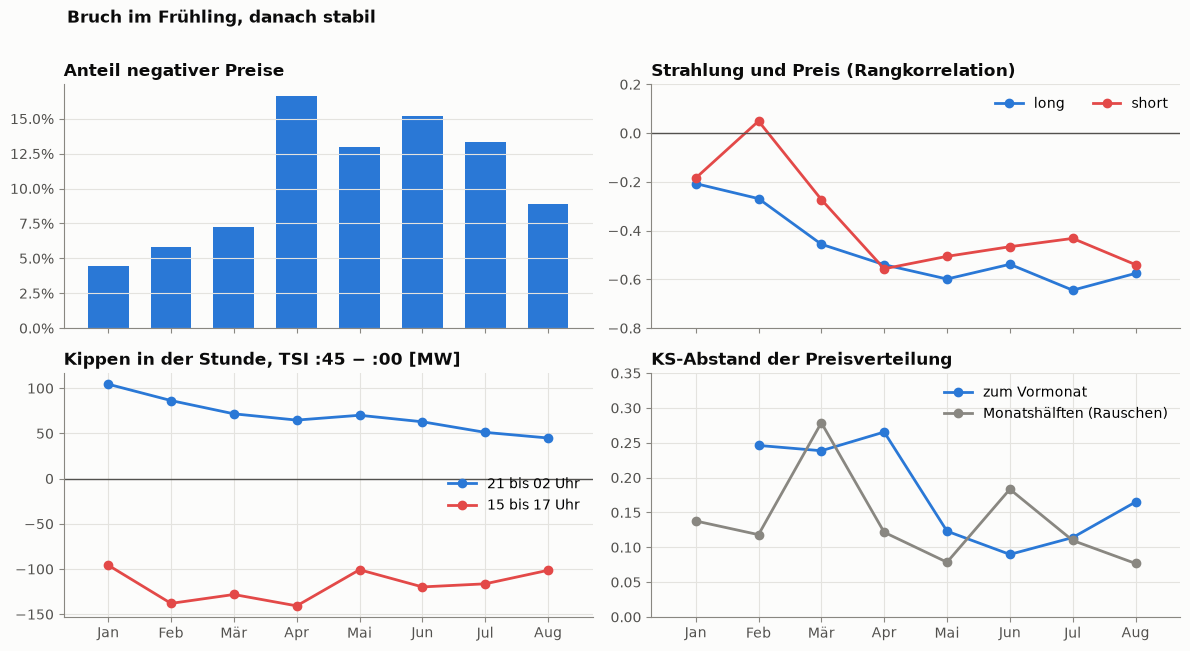

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharex=True)
x = range(len(monthly))
axes[0, 0].bar(x, monthly["negative"], color=BLUE, width=0.65)
axes[0, 0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
axes[0, 0].set(title="Anteil negativer Preise")
axes[0, 1].plot(x, monthly["rad_price_long"], color=BLUE, marker="o", label="long")
axes[0, 1].plot(x, monthly["rad_price_short"], color=RED, marker="o", label="short")
axes[0, 1].axhline(0, color=INK_2, linewidth=1)
axes[0, 1].set(title="Strahlung und Preis (Rangkorrelation)", ylim=(-0.8, 0.2))
axes[0, 1].legend(loc="upper right", ncols=2)
axes[1, 0].plot(x, monthly["flip_21_to_02"], color=BLUE, marker="o", label="21 bis 02 Uhr")
axes[1, 0].plot(x, monthly["flip_15_to_17"], color=RED, marker="o", label="15 bis 17 Uhr")
axes[1, 0].axhline(0, color=INK_2, linewidth=1)
axes[1, 0].set(title="Kippen in der Stunde, TSI :45 − :00 [MW]")
axes[1, 0].legend(loc="center right")
axes[1, 1].plot(x, monthly["ks_previous_month"], color=BLUE, marker="o", label="zum Vormonat")
axes[1, 1].plot(x, monthly["ks_month_halves"], color=MUTED, marker="o", label="Monatshälften (Rauschen)")
axes[1, 1].set(title="KS-Abstand der Preisverteilung", ylim=(0, 0.35))
axes[1, 1].legend(loc="upper right")
for ax in axes[1]:
    ax.set_xticks(x, [MONTHS[m - 1] for m in monthly.index])
for ax in axes[0]:
    ax.grid(axis="x", visible=False)
fig.suptitle("Bruch im Frühling, danach stabil", x=0.06, y=1.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
save(fig, "eda2_stability.png")
plt.show()

**F (H12):** Sind die Zusammenhänge über die Monate stabil? **A: Nein, es gibt einen Bruch im Frühling; ab April sind sie weitgehend stabil.**
- **Preisverteilung:** Der KS-Abstand zum Vormonat liegt von Februar bis April bei 0.24 bis 0.27, ab Mai bei 0.09 bis 0.16. Das ist etwa so viel wie das Rauschen zwischen den Hälften eines Monats (0.08 bis 0.18); im März erreicht dieses Rauschen 0.28, der Übergang fällt also mitten in den März. Negative Preise: 4 bis 7 % von Januar bis März, 13 bis 17 % von April bis Juli, 9 % im August.
- **Strahlung und Preis:** bei long im Januar −0.21, im März −0.46, ab April −0.54 bis −0.64; bei short ab April −0.43 bis −0.56.
- **Kippen in der Stunde (H8):** am Nachmittag (15 bis 17 Uhr) stabil zwischen −96 und −141 MW; am Abend und in der Nacht (21 bis 02 Uhr) von Januar bis August immer kleiner, von +104 auf +45 MW.
- **Tagesprofil:** Das Januar-Profil hängt mit den Sommermonaten nur zu 0.29 bis 0.45 zusammen, das Juli-Profil mit April bis August zu 0.57 bis 0.66.
- **Empfehlung Trainingsfenster:**
  1. **Baseline:** gleitende 8 Wochen; das beste Fenster in H11, und es folgt dem Wechsel der Saison.
  2. **Modelle mit Merkmalen:** alle Daten seit Januar, aber mit einem Saisonsignal (Strahlung, Tageslänge oder Monat), damit das Modell Winter und Sommer trennen kann. Beide Varianten im Backtest vergleichen.
  3. **Winterdaten behalten:** Ab Oktober bewegen sich die Liefertage auf den Winter zu. Dann sind Januar bis März die einzigen ähnlichen Monate unter dem neuen Preissystem. Herbstmonate fehlen in den Daten ganz.

---

## Fazit der zweiten Runde

| # | Ergebnis | Antwort in einem Satz |
|---|---|---|
| H9 | teilweise | Bewölkung und Standort-Streuung machen die Systembilanz unruhiger (mittags 62 gegenüber 106 MW), das Preisband aber nicht breiter. |
| H10 | widerlegt | Über Strahlung und Uhrzeit hinaus tragen die übrigen Wettervariablen nichts bei (alle Mediane zwischen −0.04 und +0.09). |
| H11 | schwach | Vergangene Preise sagen wenig (0.16 nach 2 Tagen); Quantile der Vergangenheit decken höchstens 75 % statt 80 % ab. |
| H12 | Bruch im Frühling | Von Februar bis April ändert sich die Preisverteilung stark, ab April ist sie stabil. |

**Empfehlungen für die Baseline und die Merkmale:**
- **Wettervariablen:** Strahlung (Niveau und Steigung) und Bewölkung bzw. Standort-Streuung; die übrigen vorerst weglassen.
- **Trainingsfenster:** Baseline mit gleitenden 8 Wochen; Modelle mit allen Daten seit Januar plus Saisonsignal; beide im Backtest vergleichen.
- **Unsicherheitsband:** Quantile aus der Vergangenheit allein sind zu schmal; Kalibrierung einplanen und die Abdeckung je Monat prüfen.

**Grenzen:** Preise nur von Januar bis August, Herbst fehlt. Alle Swissgrid-Werte sind final, nicht provisorisch. Die Grenze D−2 ist bis zum Abschluss der Prüfung (18.10.2026) eine Annahme.